In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
gwas_snps = {
    "rs7903146": "Diabetes",
    "rs1801282": "Diabetes",
    "rs1333049": "Heart Disease",
    "rs4977574": "Heart Disease",
    "rs2981582": "Breast Cancer",
    "rs3817198": "Breast Cancer"
}

In [6]:
np.random.seed(42)

num_samples = 300

data = []

for _ in range(num_samples):
    sample = {}
    
    # Assign SNP values
    for snp in gwas_snps:
        sample[snp] = np.random.randint(0, 3)  # 0,1,2
    
    # Assign disease based on SNP patterns
    if sample["rs7903146"] + sample["rs1801282"] > 2:
        disease = "Diabetes"
    elif sample["rs1333049"] + sample["rs4977574"] > 2:
        disease = "Heart Disease"
    elif sample["rs2981582"] + sample["rs3817198"] > 2:
        disease = "Breast Cancer"
    else:
        disease = "Healthy"
    
    sample["Disease"] = disease
    data.append(sample)

df = pd.DataFrame(data)
df.head()

,rs7903146,rs1801282,rs1333049,rs4977574,rs2981582,rs3817198,Disease
0,2,0,2,2,0,0,Heart Disease
1,2,1,2,2,2,2,Diabetes
2,0,2,1,0,1,1,Healthy
3,1,1,0,0,1,1,Healthy
4,0,0,0,2,2,2,Breast Cancer


In [8]:
le = LabelEncoder()
df["Disease"] = le.fit_transform(df["Disease"])

X = df.drop("Disease", axis=1)
y = df["Disease"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [14]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.50      0.62         8
           1       1.00      0.94      0.97        18
           2       0.81      1.00      0.90        26
           3       1.00      0.75      0.86         8

    accuracy                           0.88        60
   macro avg       0.90      0.80      0.84        60
weighted avg       0.89      0.88      0.88        60



In [16]:
importances = model.feature_importances_

feature_df = pd.DataFrame({
    "SNP": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_df

,SNP,Importance
1,rs1801282,0.226804
0,rs7903146,0.224684
2,rs1333049,0.151585
3,rs4977574,0.147436
4,rs2981582,0.129668
5,rs3817198,0.119822


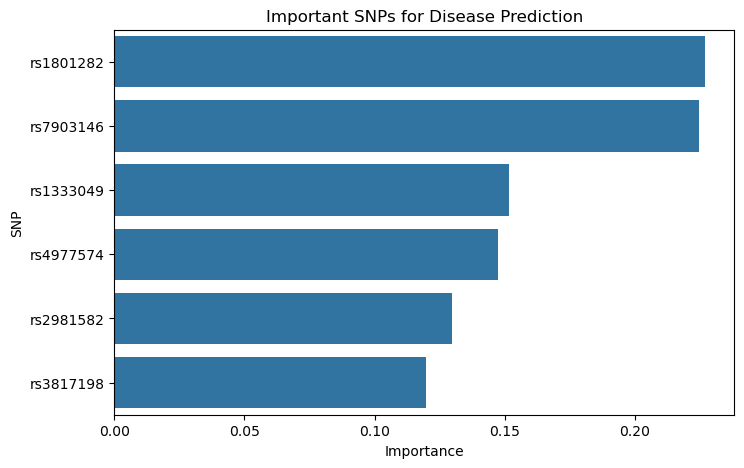

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="SNP", data=feature_df)
plt.title("Important SNPs for Disease Prediction")
plt.show()

In [20]:
new_sample = pd.DataFrame([{
    "rs7903146": 2,
    "rs1801282": 1,
    "rs1333049": 0,
    "rs4977574": 0,
    "rs2981582": 0,
    "rs3817198": 0
}])

prediction = model.predict(new_sample)
print("Predicted Disease:", le.inverse_transform(prediction))

Predicted Disease: ['Diabetes']


In [22]:
model.predict_proba(new_sample)

array([[0.   , 0.855, 0.145, 0.   ]])

In [24]:
import numpy as np
import pandas as pd

np.random.seed(42)

num_samples = 500

snp_list = [
    # Diabetes
    "rs7903146","rs1801282","rs5219","rs7756992","rs13266634","rs10811661","rs4402960","rs2237892",
    
    # Heart
    "rs1333049","rs4977574","rs10757278","rs17465637","rs599839","rs11591147","rs11206510","rs646776",
    
    # Breast cancer
    "rs2981582","rs3817198","rs889312","rs13281615","rs2046210","rs1219648","rs614367",
    
    # Obesity
    "rs9939609","rs1421085","rs1558902","rs17782313","rs7566605","rs10938397","rs2815752"
]

data = []

for _ in range(num_samples):
    sample = {}
    
    # Assign SNP values (0,1,2)
    for snp in snp_list:
        sample[snp] = np.random.randint(0, 3)
    
    # Disease logic (GWAS-inspired)
    if sample["rs7903146"] + sample["rs1801282"] + sample["rs5219"] > 4:
        disease = "Diabetes"
        
    elif sample["rs1333049"] + sample["rs4977574"] + sample["rs10757278"] > 4:
        disease = "Heart Disease"
        
    elif sample["rs2981582"] + sample["rs3817198"] + sample["rs889312"] > 4:
        disease = "Breast Cancer"
        
    elif sample["rs9939609"] + sample["rs1421085"] + sample["rs1558902"] > 4:
        disease = "Obesity"
        
    else:
        disease = "Healthy"
    
    sample["Disease"] = disease
    data.append(sample)

df = pd.DataFrame(data)
df.head()

,rs7903146,rs1801282,rs5219,rs7756992,rs13266634,rs10811661,rs4402960,rs2237892,rs1333049,rs4977574,...,rs1219648,rs614367,rs9939609,rs1421085,rs1558902,rs17782313,rs7566605,rs10938397,rs2815752,Disease
0,2,0,2,2,0,0,2,1,2,2,...,0,1,1,0,0,0,2,2,2,Heart Disease
1,1,2,1,1,2,1,2,2,0,2,...,0,1,0,1,2,2,0,2,2,Healthy
2,1,0,1,1,1,1,1,1,1,0,...,0,1,0,0,1,2,0,1,0,Breast Cancer
3,0,0,0,2,0,0,0,2,0,0,...,1,0,2,0,1,0,2,2,1,Healthy
4,0,2,1,2,2,0,2,0,2,1,...,2,1,1,0,2,2,2,0,0,Heart Disease


In [26]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Encode labels
le = LabelEncoder()
df["Disease"] = le.fit_transform(df["Disease"])

X = df.drop("Disease", axis=1)
y = df["Disease"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [29]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.29      0.44        14
           1       0.75      0.30      0.43        10
           2       0.66      1.00      0.79        56
           3       0.71      0.56      0.62         9
           4       0.00      0.00      0.00        11

    accuracy                           0.68       100
   macro avg       0.62      0.43      0.46       100
weighted avg       0.65      0.68      0.61       100



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


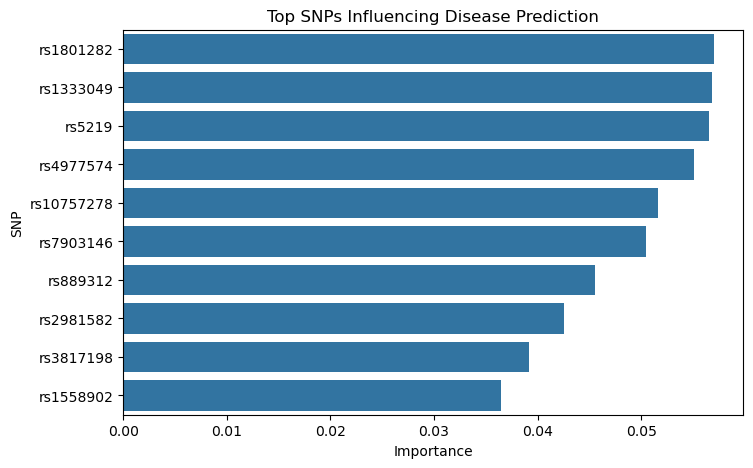

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_

feature_df = pd.DataFrame({
    "SNP": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Top 10 SNPs
top_features = feature_df.head(10)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="SNP", data=top_features)
plt.title("Top SNPs Influencing Disease Prediction")
plt.show()

In [33]:
new_sample = pd.DataFrame([np.random.randint(0,3,len(snp_list))], columns=snp_list)

prediction = model.predict(new_sample)
print("Predicted Disease:", le.inverse_transform(prediction))

Predicted Disease: ['Healthy']


In [38]:
import pickle

pickle.dump(model, open("snp_model.pkl", "wb"))
pickle.dump(le, open("label_encoder.pkl", "wb"))


In [40]:
vcf = pd.read_csv("ALL.chr22.vcf", comment="#", sep="\t")
vcf.head()


FileNotFoundError: [Errno 2] No such file or directory: 'ALL.chr22.vcf'

In [42]:
import os
os.listdir()


['Untitled Folder',
 'Untitled10.ipynb',
 'sales_pipeline01.ipynb',
 'Untitled7.ipynb',
 '.eclipse',
 'trainedmodel.ipynb',
 '.config',
 'Music',
 'self_learning_predective_analysis.ipynb',
 'predective12314123CA1.ipynb',
 'roh',
 'modeltrainaiml.ipynb',
 '.condarc',
 'Cisco Packet Tracer 8.2.2',
 'hadoop_tmp',
 'Untitled12.ipynb',
 'Untitled5.ipynb',
 'hackerthon001.ipynb',
 '.zshrcas',
 'label_encoder.pkl',
 'Untitled1.ipynb',
 '12314123HarshitBhardwaj.ipynb',
 '.DS_Store',
 'Supervised_Learning_Classification_Unit3(1).ipynb',
 'eclipse',
 '.CFUserTextEncoding',
 'pythonmap.ipynb',
 '.xonshrc',
 'derby.log',
 'snp_model.pkl',
 'anaconda_projects',
 'Untitled3.ipynb',
 'Untitled14.ipynb',
 'Untitled.ipynb',
 'DSA.cpp',
 'predictiveanalylis)3.ipynb',
 '.zshrc',
 'manasCA2.ipynb',
 'yolov8n.pt',
 '.packettracer',
 'Untitled4.ipynb',
 'Untitled13.ipynb',
 'Untitled6.ipynb',
 'employeee.txt',
 'Pictures',
 'Untitled11.ipynb',
 'Unit3.pynb.ipynb',
 '.zprofile',
 'aimlproject.ipynb',
 'Hars

In [44]:
import os
os.listdir("Downloads")

['CodeTantra.SEA-arm64-4.3.1.dmg',
 '6-Week_Java_DSA_Roadmap.docx',
 'neo_exam_checker_mac 2.dmg',
 'archive (1)',
 'WhatsApp Image 2025-04-24 at 6.28.14 PM (1).jpeg',
 'WEEK 3_watermark.pdf',
 'githhub.png',
 'googlechrome.dmg',
 'Pink_Table_Formatted_Final.pdf',
 'WhatsApp Image 2025-12-01 at 1.29.53 AM.jpeg',
 'Screenshot 2025-12-19 010209.png',
 'WhatsApp Image 2025-05-12 at 12.59.53 PM.jpeg',
 'foscopapa .pdf',
 'IMG_5232.JPG',
 'dstaset1.02.zip',
 'WhatsApp Image 2026-03-02 at 7.35.41 PM.jpeg',
 'Dynamic Memory Allocation.pptx',
 'WhatsApp Image 2025-04-24 at 6.28.17 PM.jpeg',
 'hEiNlSg0glwjqC7DfpS3j9qNjwBfDv9sps8_lH6Bwi_PZcAKzOvQwae08_oprztaFUQDRBbhzcPE.png',
 'Visual Studio Code.app',
 'IMG_5233.JPG',
 'WhatsApp Image 2025-07-14 at 22.31.26.jpeg',
 'airbnb - AB_NYC_2019.csv',
 '2white-660x441.webp',
 '291 mcqs question bank .pdf',
 'VSCode-darwin-arm64.zip',
 'Positive-Traits001-12314123.pdf',
 'WhatsApp Image 2025-04-24 at 6.28.08 PM (1).jpeg',
 'maths excel activity 3.xlsx',


In [46]:
file_name = "Downloads/ALL.chr22.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz"

vcf = pd.read_csv(
    file_name,
    compression="gzip",
    comment="#",
    sep="\t",
    nrows=10000
)

vcf.head()

,22,16050075,.,A,G,100,PASS,AC=1;AF=0.000199681;AN=5008;NS=2504;DP=8012;EAS_AF=0;AMR_AF=0;AFR_AF=0;EUR_AF=0;SAS_AF=0.001;AA=.|||;VT=SNP,GT,0|0,...,0|0.2493,0|0.2494,0|0.2495,0|0.2496,0|0.2497,0|0.2498,0|0.2499,0|0.2500,0|0.2501,0|0.2502
0,22,16050115,.,G,A,100,PASS,AC=32;AF=0.00638978;AN=5008;NS=2504;DP=11468;E...,GT,0|0,...,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0
1,22,16050213,.,C,T,100,PASS,AC=38;AF=0.00758786;AN=5008;NS=2504;DP=15092;E...,GT,0|0,...,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0
2,22,16050319,.,C,T,100,PASS,AC=1;AF=0.000199681;AN=5008;NS=2504;DP=22609;E...,GT,0|0,...,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0
3,22,16050527,.,C,A,100,PASS,AC=1;AF=0.000199681;AN=5008;NS=2504;DP=23591;E...,GT,0|0,...,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0
4,22,16050568,.,C,A,100,PASS,AC=2;AF=0.000399361;AN=5008;NS=2504;DP=21258;E...,GT,0|0,...,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0


In [48]:
vcf = vcf.rename(columns={"#CHROM": "CHROM"})  # just in case
vcf = vcf[["ID"] + list(vcf.columns[9:])]   # SNP ID + all individuals

KeyError: "['ID'] not in index"

In [50]:
print(vcf.columns)


Index(['22', '16050075', '.', 'A', 'G', '100', 'PASS',
       'AC=1;AF=0.000199681;AN=5008;NS=2504;DP=8012;EAS_AF=0;AMR_AF=0;AFR_AF=0;EUR_AF=0;SAS_AF=0.001;AA=.|||;VT=SNP',
       'GT', '0|0',
       ...
       '0|0.2493', '0|0.2494', '0|0.2495', '0|0.2496', '0|0.2497', '0|0.2498',
       '0|0.2499', '0|0.2500', '0|0.2501', '0|0.2502'],
      dtype='object', length=2513)


In [52]:
vcf = pd.read_csv(
    file_name,
    compression="gzip",
    sep="\t",
    comment="##",   # 🔥 ONLY skip metadata lines
    header=0,
    nrows=10000
)

ValueError: Only length-1 comment characters supported

In [54]:
file_name = "Downloads/ALL.chr22.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz"

with open(file_name, "rt") as f:
    for i, line in enumerate(f):
        if line.startswith("#CHROM"):
            header_line = i
            break

print("Header at line:", header_line)

UnicodeDecodeError: 'utf-8' codec can't decode byte 0x8b in position 1: invalid start byte

In [56]:
import gzip

file_name = "Downloads/ALL.chr22.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz"

with gzip.open(file_name, "rt") as f:
    for i, line in enumerate(f):
        if line.startswith("#CHROM"):
            header_line = i
            break

print("Header at line:", header_line)

Header at line: 252


In [58]:
import pandas as pd

vcf = pd.read_csv(
    file_name,
    compression="gzip",
    sep="\t",
    skiprows=header_line,
    nrows=10000
)

vcf.rename(columns={"#CHROM": "CHROM"}, inplace=True)

vcf.head()

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,HG00096,...,NA21128,NA21129,NA21130,NA21133,NA21135,NA21137,NA21141,NA21142,NA21143,NA21144
0,22,16050075,.,A,G,100,PASS,AC=1;AF=0.000199681;AN=5008;NS=2504;DP=8012;EA...,GT,0|0,...,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0
1,22,16050115,.,G,A,100,PASS,AC=32;AF=0.00638978;AN=5008;NS=2504;DP=11468;E...,GT,0|0,...,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0
2,22,16050213,.,C,T,100,PASS,AC=38;AF=0.00758786;AN=5008;NS=2504;DP=15092;E...,GT,0|0,...,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0
3,22,16050319,.,C,T,100,PASS,AC=1;AF=0.000199681;AN=5008;NS=2504;DP=22609;E...,GT,0|0,...,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0
4,22,16050527,.,C,A,100,PASS,AC=1;AF=0.000199681;AN=5008;NS=2504;DP=23591;E...,GT,0|0,...,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0,0|0


In [60]:
 vcf = vcf[["ID", "HG00096"]]

In [62]:
vcf = vcf[["ID", "HG00096"]]
vcf.head()

,ID,HG00096
0,.,0|0
1,.,0|0
2,.,0|0
3,.,0|0
4,.,0|0


In [64]:
def convert_gt(gt):
    if "0|0" in str(gt) or "0/0" in str(gt):
        return 0
    elif "0|1" in str(gt) or "1|0" in str(gt):
        return 1
    elif "1|1" in str(gt):
        return 2
    else:
        return 0

vcf["HG00096"] = vcf["HG00096"].apply(convert_gt)
vcf.head()

,ID,HG00096
0,.,0
1,.,0
2,.,0
3,.,0
4,.,0


In [66]:
model_snps = list(X.columns)

vcf_filtered = vcf[vcf["ID"].isin(model_snps)]

print(vcf_filtered)

Empty DataFrame
Columns: [ID, HG00096]
Index: []


In [68]:
test_sample = vcf_filtered.set_index("ID").T

In [70]:
test_sample = test_sample.reindex(columns=model_snps, fill_value=0)

In [72]:
import pickle

model = pickle.load(open("snp_model.pkl", "rb"))
le = pickle.load(open("label_encoder.pkl", "rb"))

In [74]:
prediction = model.predict(test_sample)
probability = model.predict_proba(test_sample)

print("Predicted Disease:", le.inverse_transform(prediction))
print("Probabilities:", probability)

Predicted Disease: ['Healthy']
Probabilities: [[0.08333333 0.06333333 0.77       0.05333333 0.03      ]]


In [79]:
vcf_small = vcf[["ID", "HG00096"]]
vcf_small.head()

,ID,HG00096
0,.,0
1,.,0
2,.,0
3,.,0
4,.,0


In [81]:
def convert_gt(gt):
    if "0|0" in str(gt) or "0/0" in str(gt):
        return 0
    elif "0|1" in str(gt) or "1|0" in str(gt):
        return 1
    elif "1|1" in str(gt):
        return 2
    else:
        return 0

vcf_small["HG00096"] = vcf_small["HG00096"].apply(convert_gt)

vcf_small.head()

,ID,HG00096
0,.,0
1,.,0
2,.,0
3,.,0
4,.,0


In [83]:
model_snps = list(X.columns)   # SNPs used in training

vcf_filtered = vcf_small[vcf_small["ID"].isin(model_snps)]

vcf_filtered

,ID,HG00096


In [85]:
# Convert filtered data to row format
test_sample = vcf_filtered.set_index("ID").T

# Ensure all model SNPs exist (fill missing with 0)
test_sample = test_sample.reindex(columns=model_snps, fill_value=0)

test_sample

ID,rs7903146,rs1801282,rs5219,rs7756992,rs13266634,rs10811661,rs4402960,rs2237892,rs1333049,rs4977574,...,rs2046210,rs1219648,rs614367,rs9939609,rs1421085,rs1558902,rs17782313,rs7566605,rs10938397,rs2815752
HG00096,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [87]:
import pickle

# Load model
model = pickle.load(open("snp_model.pkl", "rb"))
le = pickle.load(open("label_encoder.pkl", "rb"))

# Predict
prediction = model.predict(test_sample)
probability = model.predict_proba(test_sample)

print("Predicted Disease:", le.inverse_transform(prediction))
print("Probabilities:", probability)

Predicted Disease: ['Healthy']
Probabilities: [[0.08333333 0.06333333 0.77       0.05333333 0.03      ]]


In [89]:
snp_list = [
# Diabetes
"rs7903146","rs1801282","rs5219","rs7756992","rs13266634",
"rs10811661","rs4402960","rs2237892","rs7901695","rs4506565",

# Heart disease
"rs1333049","rs4977574","rs10757278","rs17465637","rs599839",
"rs11591147","rs11206510","rs646776","rs6725887","rs1746048",

# Breast cancer
"rs2981582","rs3817198","rs889312","rs13281615","rs2046210",
"rs1219648","rs614367","rs10941679","rs3803662","rs4973768",

# Obesity
"rs9939609","rs1421085","rs1558902","rs17782313","rs7566605",
"rs10938397","rs2815752","rs6548238","rs7498665","rs10150332",

# Extra SNPs
"rs1111875","rs5215","rs7578597","rs1801214","rs10401969",
"rs1121980","rs12970134","rs10913469","rs2736100","rs6983267"
]

In [91]:
snp_weights = {
    "rs7903146": 2.5,
    "rs1801282": 1.8,
    "rs5219": 1.6,
    "rs1333049": 2.2,
    "rs4977574": 2.0,
    "rs2981582": 2.3,
    "rs9939609": 2.4,
    # default weight = 1 for others
}

In [93]:
data = []

for _ in range(500):
    sample = {}

    for snp in snp_list:
        sample[snp] = np.random.randint(0,3)

    # Weighted score calculation
    diabetes_score = (
        sample["rs7903146"]*2.5 +
        sample["rs1801282"]*1.8 +
        sample["rs5219"]*1.6
    )

    heart_score = (
        sample["rs1333049"]*2.2 +
        sample["rs4977574"]*2.0
    )

    cancer_score = (
        sample["rs2981582"]*2.3
    )

    obesity_score = (
        sample["rs9939609"]*2.4
    )

    # Assign disease
    if diabetes_score > 5:
        disease = "Diabetes"
    elif heart_score > 4:
        disease = "Heart Disease"
    elif cancer_score > 3:
        disease = "Breast Cancer"
    elif obesity_score > 4:
        disease = "Obesity"
    else:
        disease = "Healthy"

    sample["Disease"] = disease
    data.append(sample)

df = pd.DataFrame(data)

In [95]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

le = LabelEncoder()
df["Disease"] = le.fit_transform(df["Disease"])

X = df.drop("Disease", axis=1)
y = df["Disease"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestClassifier(n_estimators=300)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300)

In [97]:
importances = model.feature_importances_

feature_df = pd.DataFrame({
    "SNP": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_df.head(10)

,SNP,Importance
0,rs7903146,0.118074
1,rs1801282,0.075607
2,rs5219,0.070090
10,rs1333049,0.061037
20,rs2981582,0.027899
30,rs9939609,0.022505
11,rs4977574,0.018716
9,rs4506565,0.016883
4,rs13266634,0.015797
23,rs13281615,0.015658


In [2]:
prs_weights = {
    # Diabetes SNPs
    "rs7903146": 0.35,
    "rs1801282": 0.25,
    "rs5219": 0.20,
    "rs13266634": 0.30,
    
    # Heart disease
    "rs1333049": 0.40,
    "rs4977574": 0.38,
    "rs10757278": 0.32,
    
    # Breast cancer
    "rs2981582": 0.45,
    "rs3817198": 0.30,
    
    # Obesity
    "rs9939609": 0.42,
    "rs1421085": 0.36
}

In [4]:
def calculate_prs(sample):
    score = 0
    for snp, weight in prs_weights.items():
        score += sample.get(snp, 0) * weight
    return score

In [6]:
prs_score = calculate_prs(test_sample.iloc[0])

print("PRS Score:", prs_score)

NameError: name 'test_sample' is not defined

In [106]:
# Get SNPs used in model
model_snps = list(X.columns)

# Filter from your processed VCF
vcf_filtered = vcf_small[vcf_small["ID"].isin(model_snps)]

# Convert to row format
test_sample = vcf_filtered.set_index("ID").T

# Fill missing SNPs
test_sample = test_sample.reindex(columns=model_snps, fill_value=0)

test_sample

NameError: name 'vcf_small' is not defined

In [108]:
import pandas as pd
import gzip

# STEP 1: Load VCF correctly
file_name = "Downloads/ALL.chr22.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz"

with gzip.open(file_name, "rt") as f:
    for i, line in enumerate(f):
        if line.startswith("#CHROM"):
            header_line = i
            break

vcf = pd.read_csv(
    file_name,
    compression="gzip",
    sep="\t",
    skiprows=header_line,
    nrows=10000
)

vcf.rename(columns={"#CHROM": "CHROM"}, inplace=True)

# STEP 2: Select one individual
vcf_small = vcf[["ID", "HG00096"]]

# STEP 3: Convert genotype
def convert_gt(gt):
    if "0|0" in str(gt) or "0/0" in str(gt):
        return 0
    elif "0|1" in str(gt) or "1|0" in str(gt):
        return 1
    elif "1|1" in str(gt):
        return 2
    else:
        return 0

vcf_small["HG00096"] = vcf_small["HG00096"].apply(convert_gt)

# STEP 4: Match model SNPs
model_snps = list(X.columns)

vcf_filtered = vcf_small[vcf_small["ID"].isin(model_snps)]

# STEP 5: Convert to model format
test_sample = vcf_filtered.set_index("ID").T
test_sample = test_sample.reindex(columns=model_snps, fill_value=0)

test_sample.head()

/var/folders/r2/tyb134fj0gxdpbp95t28qg9h0000gn/T/ipykernel_37387/1093105260.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vcf_small["HG00096"] = vcf_small["HG00096"].apply(convert_gt)


ID,rs7903146,rs1801282,rs5219,rs7756992,rs13266634,rs10811661,rs4402960,rs2237892,rs7901695,rs4506565,...,rs1111875,rs5215,rs7578597,rs1801214,rs10401969,rs1121980,rs12970134,rs10913469,rs2736100,rs6983267
HG00096,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [110]:
prs_score = calculate_prs(test_sample.iloc[0])
print("PRS Score:", prs_score)

PRS Score: 0.0


In [114]:
test_sample.loc[test_sample.index[0], "rs7903146"] = 2
test_sample.loc[test_sample.index[0], "rs1801282"] = 1
test_sample.loc[test_sample.index[0], "rs1333049"] = 2
test_sample.loc[test_sample.index[0], "rs9939609"] = 1

In [116]:
prs_score = calculate_prs(test_sample.iloc[0])
print("PRS Score:", prs_score)

PRS Score: 2.17


In [118]:
import matplotlib.pyplot as plt

scores = disease_prs(test_sample.iloc[0])

diseases = list(scores.keys())
values = list(scores.values())

plt.figure()
plt.bar(diseases, values)

plt.xlabel("Diseases")
plt.ylabel("PRS Score")
plt.title("Disease Risk Based on SNP Profile")

plt.show()

NameError: name 'disease_prs' is not defined

In [120]:
def disease_prs(sample):

    diabetes = (
        sample.get("rs7903146",0)*0.35 +
        sample.get("rs1801282",0)*0.25 +
        sample.get("rs5219",0)*0.20
    )

    heart = (
        sample.get("rs1333049",0)*0.40 +
        sample.get("rs4977574",0)*0.38 +
        sample.get("rs10757278",0)*0.32
    )

    cancer = (
        sample.get("rs2981582",0)*0.45 +
        sample.get("rs3817198",0)*0.30
    )

    obesity = (
        sample.get("rs9939609",0)*0.42 +
        sample.get("rs1421085",0)*0.36
    )

    return {
        "Diabetes": diabetes,
        "Heart Disease": heart,
        "Breast Cancer": cancer,
        "Obesity": obesity
    }

In [122]:
scores = disease_prs(test_sample.iloc[0])
print(scores)

{'Diabetes': 0.95, 'Heart Disease': 0.8, 'Breast Cancer': 0.0, 'Obesity': 0.42}


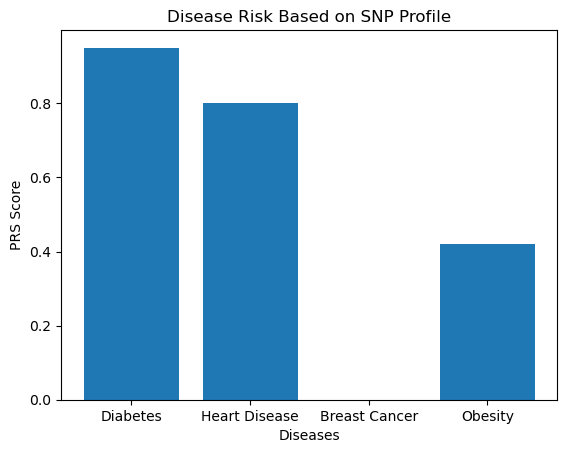

In [124]:
import matplotlib.pyplot as plt

# Use your already calculated scores
scores = disease_prs(test_sample.iloc[0])

diseases = list(scores.keys())
values = list(scores.values())

plt.figure()
plt.bar(diseases, values)

plt.xlabel("Diseases")
plt.ylabel("PRS Score")
plt.title("Disease Risk Based on SNP Profile")

plt.show()

In [129]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [131]:
app.py


NameError: name 'app' is not defined